<img src=https://courseware.decoded.com/images/decoded/logo-decoded.png align=left width=100px/>

# M07 Rapid Machine Learning

---
<small>© 2026 Decoded Limited. All rights reserved. Website: https://decoded.com </small>

### Rapid Machine Learning with PyCaret
Welcome! In this notebook, we will use **PyCaret** to rapidly build, tune, and deploy machine learning models. 

We are taking it a step further than basic scripts: we will build a **reusable Python module** capable of handling *both* **Classification** and **Regression** tasks, use **scikit-learn** for robust data splitting, and then save (pickle) our pipelines for future use.

**PyCaret** is designed to make this incredibly easy. In this notebook, we will walk through the core PyCaret workflow:
1. **Setup:** Prepare the data.
2. **Compare:** Rapidly test multiple algorithms to find the best one.
3. **Tune:** Optimize the winning algorithm's parameters.
4. **Deploy:** Save the final model for real-world use.

In [2]:
# Install pycaret (uncomment the line below if running for the first time in this environment)
# !pip install pycaret

# 0.Loading The Data From A GitHub Repository

follow the steps below on your terminal 

open a new terminal:

use ls to see the files in the current directory

lab00@hub3050:~$ ls

then use cd to navigate to the directory we want the data to be in 

lab00@hub3050:~$ cd Documents

for this tutorial we want the data to be in a directory called my-work, so we will navigate to that directory

lab00@hub3050:~$ cd my-work

now we will use git clone to clone the repository that contains the data for this tutorial

lab00@hub3050:~/Documents/my-work$ git clone https://github.com/bostonpaul-rgb/product_folder.git

you should see a output similar to this:
Cloning into 'product_folder'...
remote: Enumerating objects: 6, done.
remote: Counting objects: 100% (6/6), done.
remote: Compressing objects: 100% (4/4), done.
remote: Total 6 (delta 0), reused 3 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (6/6), 13.34 KiB | 13.34 MiB/s, done.

now we can navigate to the product_folder directory to see the data 



## 1. The Data: Loading and Splitting
We need two datasets to experiment workflows studied in this accelerator programme:
1. **Juice (Classification):** Predicting customer beverage brand preferences.
2. **Insurance (Regression):** Predicting medical charges based on patient attributes.

We will use `scikit-learn` to cleanly split off 20% of our data as an "unseen" holdout set to test our final loaded pipelines.

In [2]:
from pycaret.datasets import get_data
from sklearn.model_selection import train_test_split
import pandas as pd


# 2. Regression Data
reg_data = get_data('insurance')




,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


Regression Data Setup: (1070, 7) train, (268, 7) unseen


In [3]:
reg_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [ ]:
# Code here to perform train_test_split
reg_train, reg_unseen = train_test_split(reg_data, test_size=0.2, random_state=42)

# Reset indices for clean dataframes


# Print some basic information for our data 
print(f"Regression Data Setup: {reg_train.shape} train, {reg_unseen.shape} unseen")


## 2 Building the rapid model build pipeline

#### Step 1: Setup the Environment
The `setup()` function initializes the training environment and creates the transformation pipeline. It automatically infers data types and prepares everything for modeling behind the scenes.

In [4]:
from pycaret.regression import *

# We tell PyCaret what dataset to use and which column is our target.
# session_id ensures our results are reproducible (like a random seed).
# Set Purchase as our target


,Description,Value
0,Session id,123
1,Target,charges
2,Target type,Regression
3,Original data shape,"(1070, 7)"
4,Transformed data shape,"(1070, 10)"
5,Transformed train set shape,"(749, 10)"
6,Transformed test set shape,"(321, 10)"
7,Numeric features,3
8,Categorical features,3
9,Preprocess,True


#### Step 2: Rapid Model Build (`compare_models`)
Instead of guessing which algorithm will work best, we use `compare_models()`. This function trains and evaluates a library of over 15 standard machine learning algorithms using cross-validation, and ranks them by performance.

In [5]:
# This will output a leaderboard of models. 
# It returns the top-performing model object.

# You can add arguments to res



,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
gbr,Gradient Boosting Regressor,2710.2353,23502568.2800,4813.4083,0.8334,0.4028,0.2818,0.0660
lightgbm,Light Gradient Boosting Machine,2952.7559,25239447.0389,4995.1861,0.8205,0.5101,0.3256,0.0420
rf,Random Forest Regressor,2862.2343,26093409.5420,5083.1201,0.8150,0.4288,0.2981,0.1260
ada,AdaBoost Regressor,4274.7232,28325743.6392,5312.6152,0.7969,0.5814,0.6558,0.0320
et,Extra Trees Regressor,2906.2715,28718678.5069,5328.2215,0.7961,0.4404,0.2997,0.1040
xgboost,Extreme Gradient Boosting,3187.9157,29382247.2000,5396.8619,0.7909,0.4847,0.3609,0.0480
ridge,Ridge Regression,4132.3647,37840853.3615,6123.7840,0.7280,0.5767,0.4132,0.0240
lr,Linear Regression,4111.6803,37836833.4522,6123.5096,0.7279,0.5706,0.4093,0.0260
lasso,Lasso Regression,4111.6195,37832413.7470,6123.1281,0.7279,0.5719,0.4093,0.0280
lar,Least Angle Regression,4111.6803,37836833.4522,6123.5096,0.7279,0.5706,0.4093,0.0260


#### Step 3: Inspecting Model Parameters
What exactly is `best_model`? It is an actual scikit-learn (or similar) model object with default parameters. Let's print it to see its internal settings.

In [6]:
print("--- Best Baseline Model Parameters ---")
print(best_model)

--- Best Baseline Model Parameters ---
GradientBoostingRegressor(random_state=123)


#### Step 4: Tune the Model
Our `best_model` did well, but it is just using default settings. The `tune_model()` function automatically searches through a grid of hyperparameters to squeeze out even better performance.

In [7]:
# Tune the hyperparameters of the best model

# Let's look at the parameters now. Notice how they have changed from the baseline!


,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,3867.8226,33832972.1023,5816.6117,0.7870,0.5270,0.3940
1,3449.5566,33978494.4396,5829.1075,0.7633,0.6157,0.3989
2,3072.5452,22275939.1870,4719.7393,0.8388,0.5717,0.3946
3,3108.9756,24498204.5935,4949.5661,0.7628,0.6821,0.4082
4,3716.8552,31977649.3637,5654.8784,0.8036,0.5678,0.4351
Mean,3443.1510,29312651.9372,5393.9806,0.7911,0.5929,0.4062
Std,317.5918,4939632.0003,466.5031,0.0284,0.0527,0.0153


Fitting 5 folds for each of 10 candidates, totalling 50 fits
Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).

--- Tuned Model Parameters ---
GradientBoostingRegressor(random_state=123)


#### Step 5: Deploy (Save the Model)
Once we are happy with our tuned model, we need to save it so we can use it in a real application (like a web app or an automated script). 

`save_model()` bundles the tuned model AND the entire data preparation pipeline into a single downloadable file.

In [16]:
# Save the model to your hard drive


Transformation Pipeline and Model Successfully Saved

Success! Your model is now saved as 'my_first_deployment_pipeline.pkl' and ready for the real world.


### 3. Model Pickling & Inference on test data
Finally, we save both pipelines, load them back up using the respective PyCaret function, and make predictions on the unseen data we set aside earlier.

In [17]:
# 1. Load the saved pipeline
# Notice we don't need to add the '.pkl' extension, PyCaret handles it!


Loading saved pipeline...
Transformation Pipeline and Model Successfully Loaded


In [18]:
# 2. Make predictions on the test/holdout data
# By default, if we don't pass a new dataframe to the 'data' parameter, 
# PyCaret automatically uses the test set it created during setup().



Generating predictions on the test data...


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Linear Discriminant Analysis,0.8677,0.9131,0.8677,0.8673,0.8675,0.7207,0.7208


In [19]:
# 3. View the results
# PyCaret adds two new columns to the end of the dataframe:


,Purchase,prediction_label,prediction_score
45,MM,CH,0.6658
340,MM,MM,0.8133
224,CH,CH,0.9628
406,CH,CH,0.9496
506,CH,CH,0.9894
488,CH,CH,0.9559
802,CH,MM,0.9384
159,MM,MM,0.5502
760,CH,CH,0.8966
89,MM,MM,0.9946


### 4 Visualising Model Performance (Confusion Matrix)
Numbers are great, but visuals are better. We want to see exactly how many predictions our model got right, and where it got "confused" (e.g., predicting Citrus Hill when the customer actually bought Minute Maid).

PyCaret's `plot_model()` function automatically evaluates your trained model on the holdout test set and generates beautiful interactive charts. Let's look at the Confusion Matrix.

Generating Confusion Matrix...


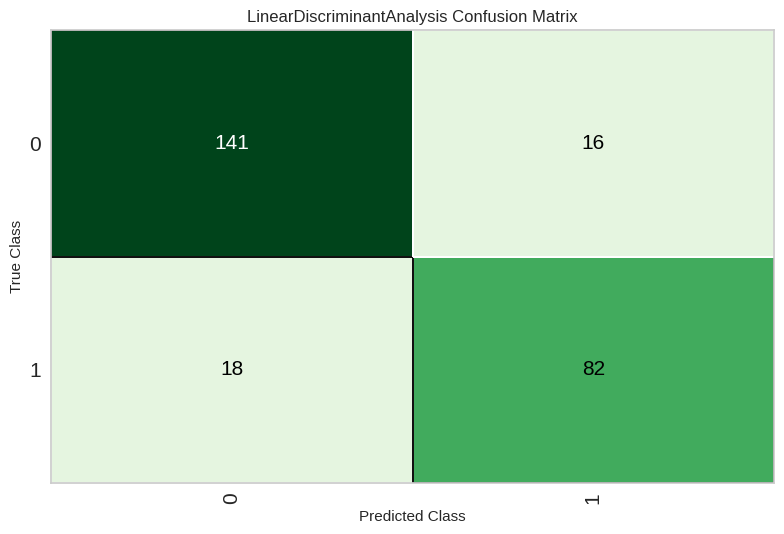

In [20]:
# Plot the confusion matrix for our tuned model
print("Generating Confusion Matrix...")
plot_model(tuned_model, plot='confusion_matrix')

# Note: You can also explore other plots just by changing the 'plot' parameter!
# Try uncommenting the lines below:
# plot_model(tuned_model, plot='feature')  # Feature Importance
# plot_model(tuned_model, plot='auc')      # ROC-AUC Curve

## 5. The Reusable Module (Classification & Regression) (Optional)
To make our code clean and reusable, we will build . By using PyCaret's modern Object-Oriented API (`ClassificationExperiment` and `RegressionExperiment`), we can easily switch between task types without global state conflicts.

File: `readme.md`

```bash
rapid-ml-project/
│
├── data/                   # Store local datasets here
│
├── models/                 # Your saved PyCaret pipelines (.pkl) will go here
│
├── notebooks/              # Jupyter notebooks for EDA and initial experimentation
│   ├── pycaret_eda_tutorial.ipynb
│   └── pycaret_mlflow_tutorial.ipynb
│
├── src/                    # Source code for your reusable ML modules
│   ├── __init__.py         # Makes 'src' a recognisable Python module
│   └── ml_pipeline.py      # The custom PyCaret functions we built
│
├── main.py                 # The execution script that runs the pipeline
├── requirements.txt        # List of required Python packages
└── README.md               # The manual for your project

```

### 1. The Core Module (`ml_pipeline.py`)

This script contains our reusable functions. Notice how we return the `exp` (the PyCaret experiment instance) alongside the model so that we can pass it into our saving and predicting functions later.

```python
from pycaret.classification import ClassificationExperiment
from pycaret.regression import RegressionExperiment

def build_and_tune_model(data, target_col, task_type='classification', experiment_name=None, session_id=123):
    """
    Initializes PyCaret, compares models, tunes the best one, and logs to MLflow.
    Returns the tuned model and the active PyCaret experiment instance.
    """
    print(f"\n--- Starting {task_type.upper()} Pipeline ---")
    
    # 1. Initialize the correct PyCaret Experiment
    if task_type.lower() == 'classification':
        exp = ClassificationExperiment()
        sort_metric = 'Accuracy'
    elif task_type.lower() == 'regression':
        exp = RegressionExperiment()
        sort_metric = 'R2'
    else:
        raise ValueError("task_type must be either 'classification' or 'regression'")
        
    # 2. Setup with MLflow tracking enabled
    exp_name = experiment_name or f"rapidml_{task_type}_experiment"
    exp.setup(
        data=data, 
        target=target_col, 
        session_id=session_id, 
        log_experiment=True, 
        experiment_name=exp_name,
        verbose=False
    )
    
    # 3. Compare Baseline Models
    print(f"Finding best baseline model (optimizing for {sort_metric})...")
    best_model = exp.compare_models(sort=sort_metric)
    
    # 4. Tune the Best Model
    print("Tuning the best model...")
    tuned_model = exp.tune_model(best_model)
    
    print("Pipeline Complete!")
    return tuned_model, exp


def save_pipeline(exp_instance, model, filename):
    """Pickles the model and the entire preprocessing pipeline."""
    exp_instance.save_model(model, filename)
    print(f"Model and pipeline successfully saved to {filename}.pkl")


def load_and_predict(exp_instance, filename, unseen_data):
    """Loads a saved pipeline and generates predictions on new data."""
    print(f"Loading pipeline from {filename}.pkl...")
    loaded_pipeline = exp_instance.load_model(filename)
    
    print("Generating predictions...")
    predictions = exp_instance.predict_model(loaded_pipeline, data=unseen_data)
    return predictions

```



### 2. The execution script (`main.py`)

This script imports the functions we just built and uses them to process our data end-to-end. This makes your execution code incredibly readable!

```python
import pandas as pd
from pycaret.datasets import get_data
from sklearn.model_selection import train_test_split

# Import our custom functions (assuming they are saved in ml_pipeline.py)
# from ml_pipeline import build_and_tune_model, save_pipeline, load_and_predict

if __name__ == "__main__":
    # --- 1. DATA PREPARATION ---
    print("Loading and splitting data...")
    juice_data = get_data('juice', verbose=False)
    clf_train, clf_unseen = train_test_split(juice_data, test_size=0.05, random_state=42)
    
    insurance_data = get_data('insurance', verbose=False)
    reg_train, reg_unseen = train_test_split(insurance_data, test_size=0.05, random_state=42)

    # --- 2. CLASSIFICATION WORKFLOW ---
    clf_model, clf_exp = build_and_tune_model(
        data=clf_train, 
        target_col='Purchase', 
        task_type='classification', 
        experiment_name='Juice_Functions_Exp'
    )
    
    save_pipeline(clf_exp, clf_model, 'functional_clf_pipeline')
    
    clf_predictions = load_and_predict(clf_exp, 'functional_clf_pipeline', clf_unseen)
    print("\nClassification Predictions:")
    print(clf_predictions[['Purchase', 'prediction_label', 'prediction_score']].head())

    # --- 3. REGRESSION WORKFLOW ---
    reg_model, reg_exp = build_and_tune_model(
        data=reg_train, 
        target_col='charges', 
        task_type='regression',
        experiment_name='Insurance_Functions_Exp'
    )
    
    save_pipeline(reg_exp, reg_model, 'functional_reg_pipeline')
    
    reg_predictions = load_and_predict(reg_exp, 'functional_reg_pipeline', reg_unseen)
    print("\nRegression Predictions:")
    print(reg_predictions[['charges', 'prediction_label']].head())

```

